In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import load_model
import joblib
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
df = pd.read_csv('../../dataset_dl.csv')

In [ ]:
def directional_accuracy(y_true, y_pred):
    """Función para calcular la precisión direccional entre los valores verdaderos y las predicciones.
    Parámetros:
    y_true: Array de valores verdaderos
    y_pred: Array de valores predichos
    Retorna:
    Precisión direccional: Proporción de predicciones que tienen la misma dirección que los valores verdaderos (positivo, negativo o sin cambio)
    """
    true_dir = np.sign(y_true)
    pred_dir = np.sign(y_pred)
    valid = true_dir != 0
    if valid.sum() == 0:
        return 0
    return np.mean(true_dir[valid] == pred_dir[valid])

In [ ]:
def crear_secuencias(dataframe, input_length, output_length):
    """
    Crea secuencias supervisadas para LSTM.
    Parametros:
    dataframe: Dataset sobre el que se crean las secuencias
    input_length: Tamaño de entrada
    output_length: Tamañ de salida
    Retorna:
    X: Array de los primeros valores (Desde 0 hasta input_length)
    Y: Array con los demás valores
    """
    X, Y = [], []
    values = dataframe.values
    
    for i in range(len(values) - input_length - output_length):
        X.append(values[i:i+input_length, :])
        Y.append(values[i+input_length:i+input_length+output_length, -1])
    
    X = np.array(X)
    Y = np.array(Y).reshape(-1, output_length, 1)
    
    return X, Y

In [5]:
INPUT_LENGTH = 12      # Debe coincidir con el entrenamiento
OUTPUT_LENGTH = 6      # Debe coincidir con el entrenamiento

# %%
# Cargar el modelo guardado y los escaladores
modelo = load_model('lstm_model.keras')
scaler_X = joblib.load('scaler_X.pkl')
scaler_Y = joblib.load('scaler_Y.pkl')


In [ ]:
def backtesting_lstm(df, input_length, output_length, 
                     train_years=15, test_months=12, step_months=6):
    """
    Realiza backtesting con ventana deslizante para LSTM.
    
    Parámetros:
    - df: DataFrame completo
    - input_length: meses de entrada
    - output_length: meses a predecir
    - train_years: años de entrenamiento inicial
    - test_months: meses de prueba por iteración
    - step_months: desplazamiento de la ventana entre iteraciones
    
    Retorna:
    - resultados: lista con métricas por iteración
    - predicciones_acumuladas: array con todas las predicciones
    - reales_acumulados: array con todos los valores reales
    """
    
    n_total = len(df)
    train_size = train_years * 12  # Convertir años a meses
    resultados = []
    
    # Listas para almacenar predicciones y valores reales
    todas_predicciones = []
    todos_reales = []
    fechas_test = []
    
    # Posición inicial de la ventana de prueba
    inicio_test = train_size
    
    iteracion = 0
    
    while inicio_test + test_months <= n_total:
        iteracion += 1
        print(f"\n{'='*50}")
        print(f"Iteración {iteracion}")
        print(f"{'='*50}")
        
        # Definir conjuntos
        fin_train = inicio_test
        fin_test = inicio_test + test_months
        
        train_df = df.iloc[:fin_train]
        test_df = df.iloc[fin_train:fin_test]
        
        print(f"Entrenamiento: {train_df.index[0]} - {train_df.index[-1]} ({len(train_df)} meses)")
        print(f"Prueba: {test_df.index[0]} - {test_df.index[-1]} ({len(test_df)} meses)")
        
        # Crear secuencias para entrenamiento
        X_tr, Y_tr = crear_secuencias(train_df, input_length, output_length)
        
        if len(X_tr) == 0:
            print(f"No hay suficientes datos para crear secuencias en iteración {iteracion}")
            inicio_test += step_months
            continue
        
        # Escalar datos de entrenamiento
        # IMPORTANTE: Reajustar el scaler con los datos de entrenamiento de esta iteración
        scaler_X_iter = MinMaxScaler(feature_range=(-1, 1))
        scaler_Y_iter = MinMaxScaler(feature_range=(-1, 1))
        
        X_tr_reshaped = X_tr.reshape(-1, X_tr.shape[-1])
        Y_tr_reshaped = Y_tr.reshape(-1, Y_tr.shape[-1])
        
        scaler_X_iter.fit(X_tr_reshaped)
        scaler_Y_iter.fit(Y_tr_reshaped)
        
        X_tr_scaled = scaler_X_iter.transform(X_tr_reshaped).reshape(X_tr.shape)
        Y_tr_scaled = scaler_Y_iter.transform(Y_tr_reshaped).reshape(Y_tr.shape)
        
        # Crear secuencias para prueba (usando todo el train_df para crear la última secuencia)
        # Necesitamos input_length meses antes del primer mes de test
        test_start_idx = fin_train - input_length
        if test_start_idx < 0:
            print(f"No hay suficientes datos históricos para la predicción")
            inicio_test += step_months
            continue
        
        # Crear la secuencia de prueba (una sola)
        test_values = df.iloc[test_start_idx:fin_test].values
        X_ts = test_values[:input_length, :].reshape(1, input_length, -1)
        
        # Escalar datos de prueba
        X_ts_reshaped = X_ts.reshape(-1, X_ts.shape[-1])
        X_ts_scaled = scaler_X_iter.transform(X_ts_reshaped).reshape(X_ts.shape)
        
        # Reentrenar el modelo (o usar el cargado - aquí reentrenamos por simplicidad)
        # Para backtesting real, deberías reentrenar desde cero o fine-tune
        
        modelo_iter = Sequential()
        modelo_iter.add(LSTM(units=32, input_shape=(input_length, X_tr.shape[2]), 
                            return_sequences=False, dropout=0.2, recurrent_dropout=0.2))
        modelo_iter.add(Dense(output_length, activation='linear'))
        modelo_iter.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
        
        # Entrenar
        early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
        
        # Dividir entrenamiento en train/val para early stopping
        val_size = min(30, len(X_tr_scaled) // 5)
        if val_size > 0:
            X_tr_train = X_tr_scaled[:-val_size]
            Y_tr_train = Y_tr_scaled[:-val_size]
            X_tr_val = X_tr_scaled[-val_size:]
            Y_tr_val = Y_tr_scaled[-val_size:]
            validation_data = (X_tr_val, Y_tr_val)
        else:
            X_tr_train = X_tr_scaled
            Y_tr_train = Y_tr_scaled
            validation_data = None
        
        modelo_iter.fit(X_tr_train, Y_tr_train, 
                       validation_data=validation_data,
                       epochs=100, batch_size=32, 
                       callbacks=[early_stop], verbose=0)
        
        # Predecir
        Y_pred_scaled = modelo_iter.predict(X_ts_scaled, verbose=0)
        Y_pred = scaler_Y_iter.inverse_transform(Y_pred_scaled.reshape(-1, output_length))
        
        # Obtener valores reales (los output_length meses siguientes al train)
        Y_true = df.iloc[fin_train:fin_train+output_length]['target'].values
        
        # Almacenar
        todas_predicciones.extend(Y_pred.flatten())
        todos_reales.extend(Y_true)
        
        # Calcular métricas de esta iteración
        mae_iter = mean_absolute_error(Y_true, Y_pred.flatten())
        rmse_iter = np.sqrt(mean_squared_error(Y_true, Y_pred.flatten()))
        r2_iter = r2_score(Y_true, Y_pred.flatten())
        da_iter = directional_accuracy(Y_true, Y_pred.flatten())
        
        resultados.append({
            'iteracion': iteracion,
            'train_start': train_df.index[0],
            'train_end': train_df.index[-1],
            'test_start': test_df.index[0],
            'test_end': test_df.index[-1],
            'mae': mae_iter,
            'rmse': rmse_iter,
            'r2': r2_iter,
            'da': da_iter
        })
        
        print(f"Resultados iteración {iteracion}:")
        print(f"  MAE: {mae_iter:.4f}")
        print(f"  RMSE: {rmse_iter:.4f}")
        print(f"  R²: {r2_iter:.4f}")
        print(f"  DA: {da_iter:.4f}")
        
        # Mover ventana
        inicio_test += step_months
    
    return resultados, np.array(todas_predicciones), np.array(todos_reales)


In [ ]:
print(f"Dataset total: {len(df)} meses")
print(f"Input length: {INPUT_LENGTH} meses")
print(f"Output length: {OUTPUT_LENGTH} meses")

resultados, predicciones, reales = backtesting_lstm(
    df, 
    input_length=INPUT_LENGTH,
    output_length=OUTPUT_LENGTH,
    train_years=10,      # 10 años de entrenamiento inicial
    test_months=12,      # 12 meses de prueba por iteración
    step_months=6        # Desplazar ventana cada 6 meses
)

🚀 Iniciando backtesting...
Dataset total: 265 meses
Input length: 12 meses
Output length: 6 meses

Iteración 1
Entrenamiento: 0 - 119 (120 meses)
Prueba: 120 - 131 (12 meses)


c:\Users\34620\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Resultados iteración 1:
  MAE: 0.0523
  RMSE: 0.0674
  R²: -0.0465
  DA: 0.8333

Iteración 2
Entrenamiento: 0 - 125 (126 meses)
Prueba: 126 - 137 (12 meses)


c:\Users\34620\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Resultados iteración 2:
  MAE: 0.0582
  RMSE: 0.0692
  R²: -0.4413
  DA: 0.5000

Iteración 3
Entrenamiento: 0 - 131 (132 meses)
Prueba: 132 - 143 (12 meses)


...

Resultados iteración 21:
  MAE: 0.0782
  RMSE: 0.0798
  R²: -0.3269
  DA: 0.3333

Iteración 22
Entrenamiento: 0 - 245 (246 meses)
Prueba: 246 - 257 (12 meses)


c:\Users\34620\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Resultados iteración 22:
  MAE: 0.0304
  RMSE: 0.0398
  R²: -0.7284
  DA: 0.8333

Iteración 23
Entrenamiento: 0 - 251 (252 meses)
Prueba: 252 - 263 (12 meses)


c:\Users\34620\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Resultados iteración 23:
  MAE: 0.0511
  RMSE: 0.0551
  R²: -0.8435
  DA: 0.5000


In [ ]:
print("\n" + "="*60)
print("Resultados backtesting")
print("="*60)

if len(resultados) > 0:
    df_resultados = pd.DataFrame(resultados)
    
    print(f"\nNúmero de iteraciones: {len(resultados)}")
    print(f"Predicciones totales: {len(predicciones)}")
    
    print("\nMétricas medias:")
    print(f"  MAE medio: {df_resultados['mae'].mean():.4f} (±{df_resultados['mae'].std():.4f})")
    print(f"  RMSE medio: {df_resultados['rmse'].mean():.4f} (±{df_resultados['rmse'].std():.4f})")
    print(f"  R² medio: {df_resultados['r2'].mean():.4f} (±{df_resultados['r2'].std():.4f})")
    print(f"  DA medio: {df_resultados['da'].mean():.4f} (±{df_resultados['da'].std():.4f})")
    
    # Métricas globales sobre todas las predicciones
    print("\nMétricas globales:")
    mae_global = mean_absolute_error(reales, predicciones)
    rmse_global = np.sqrt(mean_squared_error(reales, predicciones))
    r2_global = r2_score(reales, predicciones)
    da_global = directional_accuracy(reales, predicciones)
    
    print(f"  MAE: {mae_global:.4f}")
    print(f"  RMSE: {rmse_global:.4f}")
    print(f"  R²: {r2_global:.4f}")
    print(f"  DA: {da_global:.4f}")
else:
    print("No se completó ninguna iteración de backtesting")



📊 RESULTADOS GLOBALES DEL BACKTESTING

Número de iteraciones: 23
Predicciones totales: 138

📈 Métricas medias:
  MAE medio: 0.0723 (±0.0294)
  RMSE medio: 0.0849 (±0.0337)
  R² medio: -0.8073 (±0.9785)
  DA medio: 0.4783 (±0.1901)

📈 Métricas globales (todas las predicciones juntas):
  MAE: 0.0723
  RMSE: 0.0910
  R²: -0.3863
  DA: 0.4783



Número de iteraciones: 23
Predicciones totales: 138

Métricas medias:
  MAE medio: 0.0716 (±0.0192)
  RMSE medio: 0.0839 (±0.0209)
  R² medio: -0.9596 (±1.0116)
  DA medio: 0.5290 (±0.1857)

Métricas globales:
  MAE: 0.0716
  RMSE: 0.0863
  R²: -0.2472
  DA: 0.5290

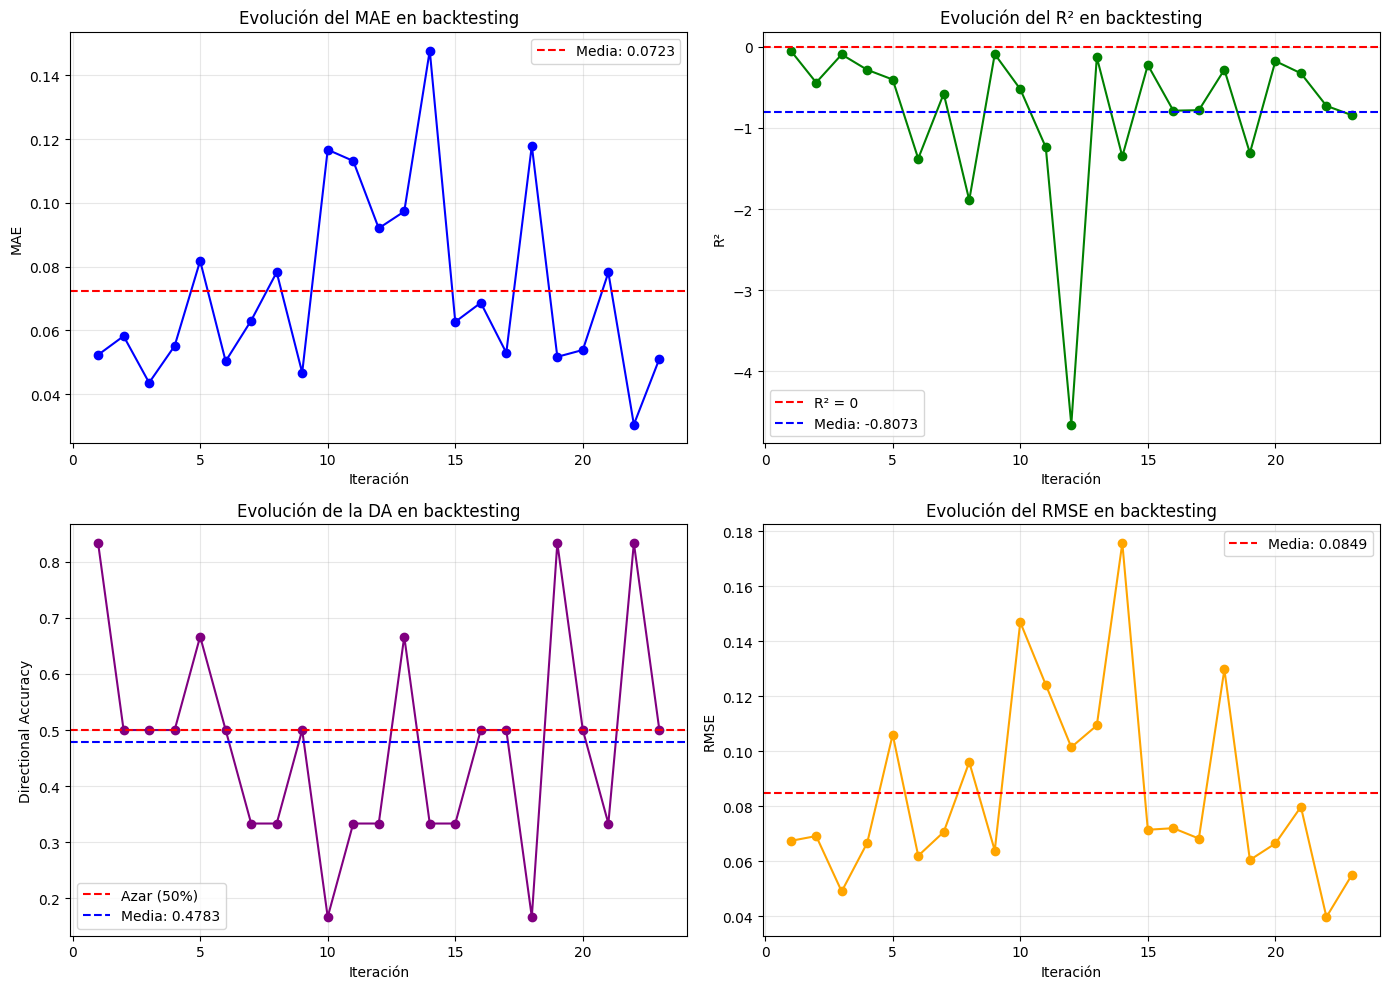

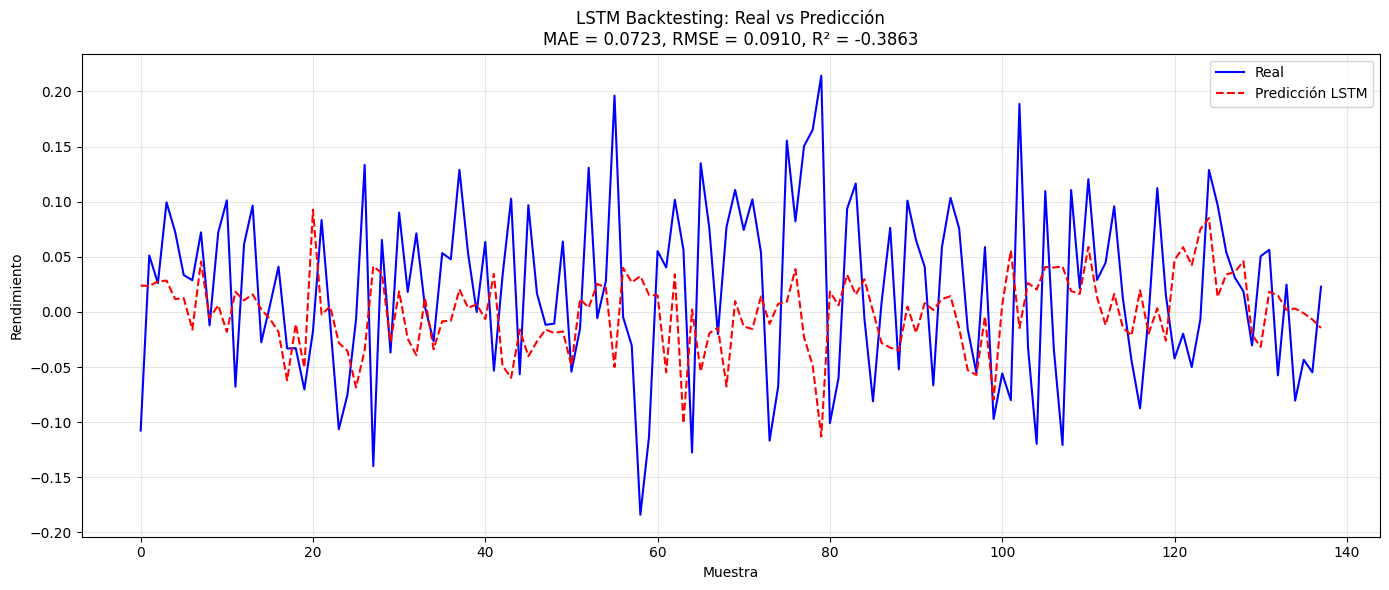

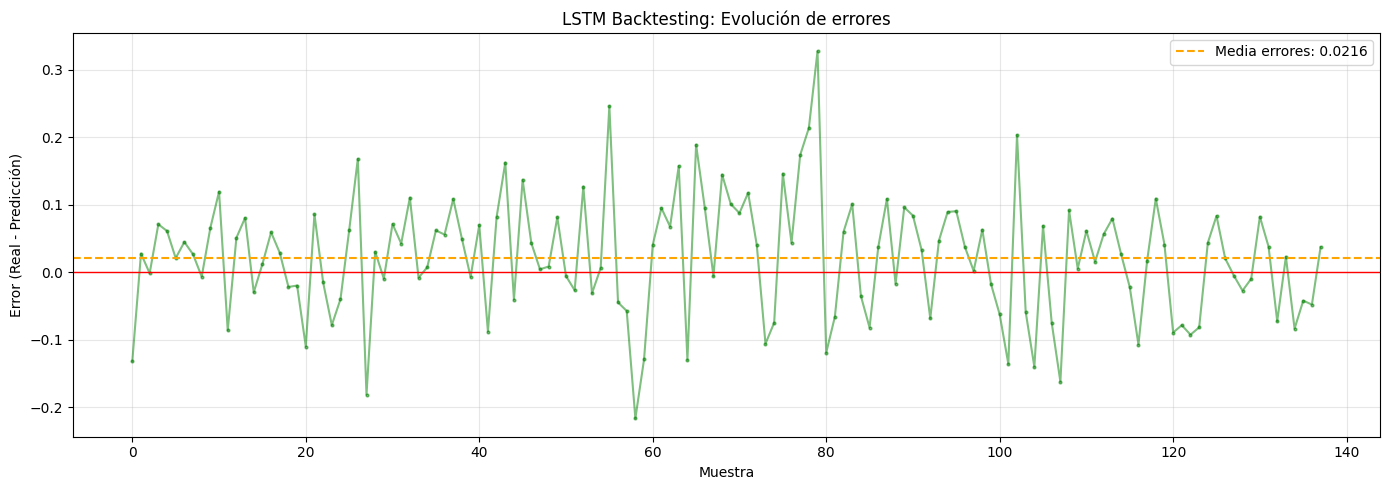

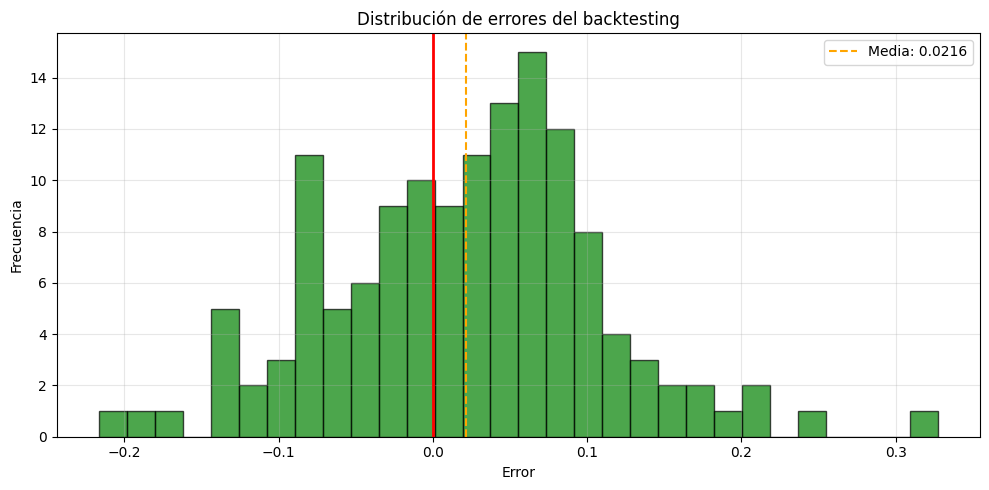

In [9]:
if len(resultados) > 0:
    # Gráfica 1: Evolución de las métricas por iteración
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    axes[0, 0].plot(df_resultados['iteracion'], df_resultados['mae'], 'o-', color='blue', linewidth=1.5)
    axes[0, 0].axhline(y=df_resultados['mae'].mean(), color='red', linestyle='--', label=f'Media: {df_resultados["mae"].mean():.4f}')
    axes[0, 0].set_xlabel('Iteración')
    axes[0, 0].set_ylabel('MAE')
    axes[0, 0].set_title('Evolución del MAE en backtesting')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    axes[0, 1].plot(df_resultados['iteracion'], df_resultados['r2'], 'o-', color='green', linewidth=1.5)
    axes[0, 1].axhline(y=0, color='red', linestyle='--', label='R² = 0')
    axes[0, 1].axhline(y=df_resultados['r2'].mean(), color='blue', linestyle='--', label=f'Media: {df_resultados["r2"].mean():.4f}')
    axes[0, 1].set_xlabel('Iteración')
    axes[0, 1].set_ylabel('R²')
    axes[0, 1].set_title('Evolución del R² en backtesting')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    axes[1, 0].plot(df_resultados['iteracion'], df_resultados['da'], 'o-', color='purple', linewidth=1.5)
    axes[1, 0].axhline(y=0.5, color='red', linestyle='--', label='Azar (50%)')
    axes[1, 0].axhline(y=df_resultados['da'].mean(), color='blue', linestyle='--', label=f'Media: {df_resultados["da"].mean():.4f}')
    axes[1, 0].set_xlabel('Iteración')
    axes[1, 0].set_ylabel('Directional Accuracy')
    axes[1, 0].set_title('Evolución de la DA en backtesting')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    axes[1, 1].plot(df_resultados['iteracion'], df_resultados['rmse'], 'o-', color='orange', linewidth=1.5)
    axes[1, 1].axhline(y=df_resultados['rmse'].mean(), color='red', linestyle='--', label=f'Media: {df_resultados["rmse"].mean():.4f}')
    axes[1, 1].set_xlabel('Iteración')
    axes[1, 1].set_ylabel('RMSE')
    axes[1, 1].set_title('Evolución del RMSE en backtesting')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('lstm_backtesting_evolucion.png', dpi=150)
    plt.show()
    
    # Gráfica 2: Real vs Predicción (todas las predicciones)
    plt.figure(figsize=(14, 6))
    n_mostrar = min(200, len(reales))
    plt.plot(range(n_mostrar), reales[:n_mostrar], label='Real', color='blue', linewidth=1.5)
    plt.plot(range(n_mostrar), predicciones[:n_mostrar], label='Predicción LSTM', color='red', linestyle='--', linewidth=1.5)
    plt.xlabel('Muestra')
    plt.ylabel('Rendimiento')
    plt.title(f'LSTM Backtesting: Real vs Predicción\nMAE = {mae_global:.4f}, RMSE = {rmse_global:.4f}, R² = {r2_global:.4f}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('lstm_backtesting_real_vs_pred.png', dpi=150)
    plt.show()
    
    # Gráfica 3: Residuos
    errores = reales - predicciones
    plt.figure(figsize=(14, 5))
    plt.plot(range(len(errores)), errores, 'o-', color='green', markersize=2, alpha=0.5)
    plt.axhline(y=0, color='red', linestyle='-', linewidth=1)
    plt.axhline(y=errores.mean(), color='orange', linestyle='--', label=f'Media errores: {errores.mean():.4f}')
    plt.xlabel('Muestra')
    plt.ylabel('Error (Real - Predicción)')
    plt.title('LSTM Backtesting: Evolución de errores')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('lstm_backtesting_residuos.png', dpi=150)
    plt.show()
    
    # Gráfica 4: Distribución de errores
    plt.figure(figsize=(10, 5))
    plt.hist(errores, bins=30, color='green', alpha=0.7, edgecolor='black')
    plt.axvline(x=0, color='red', linestyle='-', linewidth=2)
    plt.axvline(x=errores.mean(), color='orange', linestyle='--', label=f'Media: {errores.mean():.4f}')
    plt.xlabel('Error')
    plt.ylabel('Frecuencia')
    plt.title('Distribución de errores del backtesting')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('lstm_backtesting_distribucion_errores.png', dpi=150)
    plt.show()
